In [9]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Import ML models and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

In [11]:
# Set professional plotting style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [12]:
# 1. Load the dataset
df = pd.read_csv('../dataset/train.csv')

In [13]:
# 2. Quick Preprocessing (Consistent with our previous tasks)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [14]:
# Create a 'FamilySize' feature (SibSp + Parch + 1)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Drop irrelevant columns
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch'], axis=1, inplace=True)

# Encode categorical features
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

In [15]:
# 3. Define Features (X) and Target (y)
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

In [16]:
# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# 1. Baseline Single Model: Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

In [18]:
# 2. Ensemble Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [19]:
# 3. Ensemble Model 2: XGBoost
# Use use_label_encoder=False and eval_metric='logloss' to avoid XGBoost warnings
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [20]:
# Collect scores in a dictionary for easy comparison
results = {
    'Logistic Regression': {'Accuracy': accuracy_score(y_test, log_preds), 'F1-Score': f1_score(y_test, log_preds)},
    'Random Forest': {'Accuracy': accuracy_score(y_test, rf_preds), 'F1-Score': f1_score(y_test, rf_preds)},
    'XGBoost': {'Accuracy': accuracy_score(y_test, xgb_preds), 'F1-Score': f1_score(y_test, xgb_preds)}
}

In [21]:
# Print results cleanly
print("--- Model Performance Comparison ---")
for model_name, metrics in results.items():
    print(f"{model_name}: Accuracy = {metrics['Accuracy']:.4f}, F1-Score = {metrics['F1-Score']:.4f}")

--- Model Performance Comparison ---
Logistic Regression: Accuracy = 0.8045, F1-Score = 0.7518
Random Forest: Accuracy = 0.8212, F1-Score = 0.7808
XGBoost: Accuracy = 0.8268, F1-Score = 0.7832


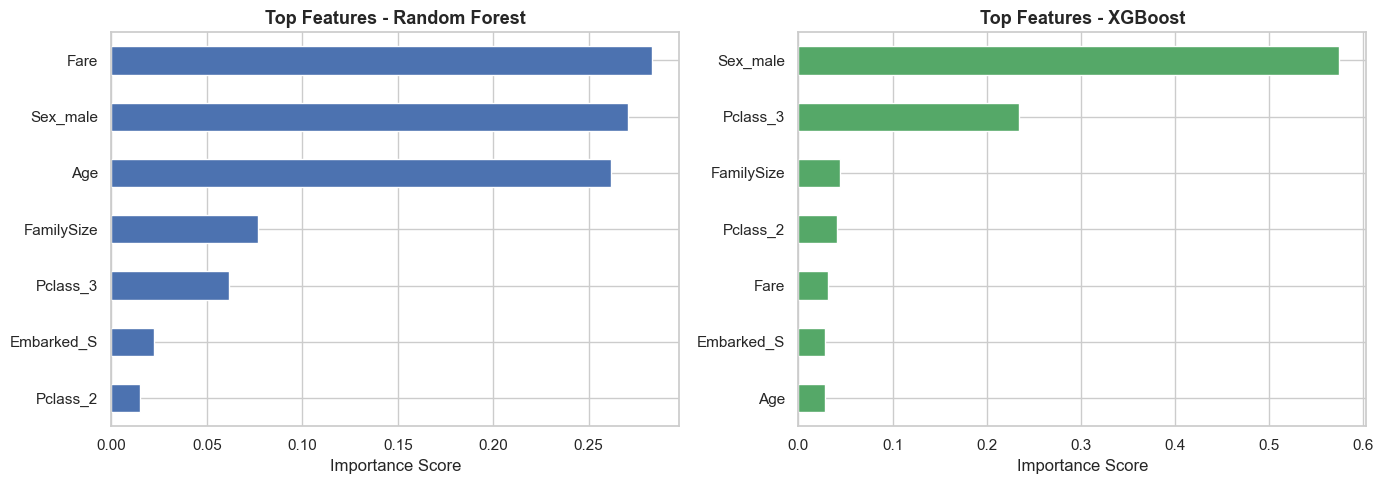

In [22]:
# Extract feature importances
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# Create a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Importances
rf_importances.tail(7).plot(kind='barh', ax=axes[0], color='#4c72b0')
axes[0].set_title('Top Features - Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Plot XGBoost Importances
xgb_importances.tail(7).plot(kind='barh', ax=axes[1], color='#55a868')
axes[1].set_title('Top Features - XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Note: You'll notice XGBoost often treats feature importance slightly differently 
# (e.g., focusing heavily on 'Sex_male' or 'Pclass' as primary splitters).

#### How Random Forest and XGBoost Combine Models?

While both are ensemble methods that use decision trees, their core mechanisms are fundamentally different. Random Forest uses a technique called Bagging (Bootstrap Aggregating), where it builds hundreds of independent trees in parallel at the same time, and then averages their predictions to reduce overfitting. XGBoost, on the other hand, uses Boosting, which builds trees sequentially; each new tree specifically focuses on correcting the errors and mistakes made by the previous trees. Because of this sequential learning, XGBoost is often more accurate and powerful, but Random Forest is generally harder to overfit and easier to tune.